In [1]:
import os
import urllib
import json

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            data = response.read().decode('utf-8')
            
        with open(file_path, 'w', encoding='utf-8') as file:
            file.write(data)
    
    else:
        with open(file_path, 'r', encoding='utf-8') as file:
            text_data = file.read()
    
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    
    return data

file_path = "instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [3]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [4]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)  # this is in alpaca format that we will use for fine-tuning

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [7]:
train_end = int(0.85 * len(data))
test_end = train_end + int(0.1 * len(data))
val_end = test_end + int(0.05 * len(data))

train_data = data[:train_end]
test_data = data[train_end:test_end]
val_data = data[test_end:val_end]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


In [8]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.encoded_texts = []
        self.data = data
        
        for entry in data:
            formatted_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = formatted_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    
    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data)

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [10]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    # +1 may seem useless here but in further implementations of this function it makes it easy to get both the input and target tensors with the correct padding and truncation
    
    batch_max_length = max(len(sample)+1 for sample in batch) 
    input_list = []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        
        inputs = torch.tensor(padded[:-1])
        input_list.append(inputs)
        
    input_tensor = torch.stack(input_list).to(device)
    return input_tensor
        

In [11]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
inputs_1,
inputs_2,
inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [12]:
# A collate function is used to take multiple individual data samples and combine them into a single batch, typically by padding and formatting them so they can be efficiently processed by the model during training. The custom collate function we are implementing here takes a batch of tokenized input sequences, pads them to the same length, and prepares them for input into the model.

def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(sample)+1 for sample in batch)
    
    inputs_list, targets_list = [], []
    
    for item in batch:
        padded_item = item + [pad_token_id]
        padded_item += [pad_token_id] * (batch_max_length - len(padded_item))
        input_item_tensor = torch.tensor(padded_item[:-1]).to(device)
        target_item_tensor = torch.tensor(padded_item[1:]).to(device)
        inputs_list.append(input_item_tensor)
        targets_list.append(target_item_tensor)
    
    input_tensor = torch.stack(inputs_list)
    target_tensor = torch.stack(targets_list)
    return input_tensor, target_tensor        

In [13]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [14]:
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    
    for item in batch:
        new_item = item.copy() + [pad_token_id]
        padded_item = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded_item[:-1])
        targets = torch.tensor(padded_item[1:])
        
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index
        
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor
            

In [15]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [16]:
logits_1 = torch.tensor(
    [[-1.0, 1.0], # predictions for 1st token
    [-0.5, 1.5]] # predictions for 2nd token
)
targets_1 = torch.tensor([0, 1]) # Correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [17]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
    [-0.5, 1.5],
    [-0.5, 1.5]] # Adding an additional token ID will, as we would expect, affect the loss calculation
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [18]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [20]:
from functools import partial 

customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024) # Create a collate function with device and max length pre-set, so DataLoader can call it with just the batch

In [21]:
from torch.utils.data import DataLoader

num_workers = 0 #A
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
train_dataset,
batch_size=batch_size,
collate_fn=customized_collate_fn,
shuffle=True,
drop_last=True,
num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
val_dataset,
batch_size=batch_size,
collate_fn=customized_collate_fn,
shuffle=False,
drop_last=False,
num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
test_dataset,
batch_size=batch_size,
collate_fn=customized_collate_fn,
shuffle=False,
drop_last=False,
num_workers=num_workers
)

In [22]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:


torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Size([8, 68])


In [23]:
from gpt_download import download_and_load_gpt2
from gpt_model import GPTModel
from load_weights_into_gpt import load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0, # Dropout rate
    "qkv_bias": True # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


In [24]:
from generate import generate
from text_to_id_to_text import text_to_token_ids, token_ids_to_text

torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

token_ids = generate(
    model=model.to(device),
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [25]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

A utensil is useful when defining each reply - but written data is simply useless. As you may have guessed, the relationship between respondments is adversarial,


In [26]:
from train_model_simple import train_model_simple

from calc_loss_loader import calc_loss_loader

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8249536037445067
Validation loss: 3.7610777854919433


In [27]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.945
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.662, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

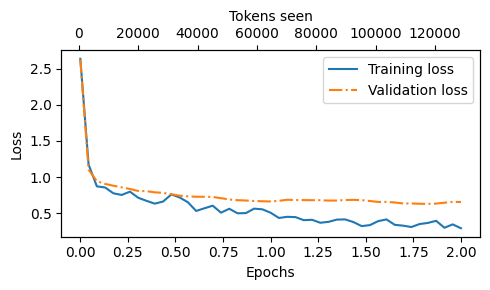

In [28]:
from plot_losses import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [29]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:","").strip()
    
    print(input_text)
    print(f"\nCorrect response:\n>>{entry['output']}")
    print(f"\nModel response:\n>>{response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>>The car is as fast as lightning.

Model response:
>>The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>>The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>>A type of cloud is typically associated with thunderstorms.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>>Jane Austen.

Model response:
>>The author of 'Pride and Prejudice' is Jan

In [30]:
print(next(enumerate(test_data)))

(0, {'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.'})


In [31]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:","").strip()
    test_data[i]['model_response'] = response_text
    
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

  0%|          | 0/110 [00:00<?, ?it/s]

100%|██████████| 110/110 [03:06<00:00,  1.70s/it]


In [32]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a cheetah.'}


In [33]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


In [34]:
import psutil

def check_if_running(process_name):
    for process in psutil.process_iter(['name']):
        if process_name in process.info['name']:
            return True
    return False

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama is not running. Launch Ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [35]:
import urllib.request

def query_model(prompt, model="llama3", url="http://localhost:11434/api/chat"):
    data = {
        "model": model,
        "seed": 123, # for deterministic responses
        "temperature": 0, # for deterministic responses
        "messages": [
            {"role": "user", "content": prompt}
        ]
    }
    
    payload = json.dumps(data).encode("utf-8")
    request = urllib.request.Request(url, data=payload, method="POST")
    request.add_header("Content-Type", "application/json") 
    
    response_data = ""
    with urllib.request.urlopen(request) as response: 
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]
            
    return response_data

In [36]:
model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay is a staple in a llama's diet. They enjoy a variety of hays, such as alfalfa, timothy, and orchard grass.
3. Grains: Llamas may also eat grains like oats, corn, and barley.
4. Fruits and vegetables: While not a main staple, llamas may enjoy fruits and vegetables like apples, carrots, and sweet potatoes as treats.
5. Leaves: Llamas may also eat leaves from trees and shrubs, like willow and cedar.
6. Browse: Browse refers to the leaves, twigs, and shoots of shrubs and small trees. Llamas often eat browse as a supplement to their diet.
7. Minerals: Llamas need access to minerals like calcium, phosphorus, and salt to stay healthy. These can be provided in the form of mineral blocks or loose minerals.

In the wild, llamas might also eat:

1. Bark: In the absence o

In [37]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.

Score:
>> To score the model response, I'll compare it to the correct output and the original instruction.

**Original Instruction:** Rewrite the sentence using a simile.

**Correct Output:** The car is as fast as lightning.

**Model Response:** The car is as fast as a cheetah.

Here's how I'd score it:

* The model response is similar to the correct output in that it's a simile that compares the car's speed to an animal's speed.
* The comparison to a cheetah is a good one, as cheetahs are known for their speed.
* The only difference is that the model response uses a slightly different animal (cheetah vs. lightning). While lightning is a more dramatic and unexpected comparison, a cheetah is still a fast and impressive animal.

Given these factors, I'd score the model response an 85 out of 100. The response is close to the correct output, uses a relevant and fitting simile, and i

In [40]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring model responses"):
        prompt = (
                    f"Given the input `{format_input(entry)}` "
                    f"and correct output `{entry['output']}`, "
                    f"score the model response `{entry[json_key]}`"
                    f" on a scale from 0 to 100, where 100 is the best score. "
                    f"Respond with the integer number only."
                ) 
        
        score = query_model(prompt, model)
        
        try:
            scores.append(int(score.strip()))
            
        except ValueError:
            print(f"Could not convert score: {score}")
            continue
        
    return scores

In [41]:
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring model responses: 100%|██████████| 110/110 [06:14<00:00,  3.41s/it]

Number of scores: 110 of 110
Average score: 46.60

